# Imports

In [1]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Macros

In [2]:
DEVICE = 'cuda'
DATASET_PATH = 'data/dataset.pt'
BATCH_SIZE = 1

# Dataset

In [3]:
class ModSeekDataset(Dataset):
    def __init__(self, qs: pd.DataFrame, sols = pd.DataFrame):
        self.qs_cols = qs.columns
        self.sols_cols = sols.columns
        
        self.num_qs = len(self.qs_cols)
        self.num_sols = len(self.sols_cols)
        
        self.qs_inst_tensor = torch.tensor(qs.to_numpy())
        self.sols_inst_tesor = torch.tensor(sols.to_numpy())
        
    def __getitem__(self, index):
        return self.qs_inst_tensor[index], self.sols_inst_tesor[index]
    
    def __len__(self):
        return len(self.qs_inst_tensor)

In [4]:
dataset: ModSeekDataset = torch.load(DATASET_PATH)
DATASET_SIZE = len(dataset)

TRAIN_RATIO = 0.9
TEST_RATIO = 1 - TRAIN_RATIO

train_len = int(DATASET_SIZE * TRAIN_RATIO)
test_len = DATASET_SIZE - train_len

torch.manual_seed(196)
train_dataset, test_dataset = random_split(dataset, (train_len, test_len))
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(len(train_loader))
print(len(test_loader))

563
63


C:\Users\agile\AppData\Local\Temp\ipykernel_14852\341987885.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset: ModSeekDataset = torch.load(DATASET_PATH)


In [5]:
print(train_loader.dataset[0])

(tensor([0., 0., 0.,  ..., 1., 0., 1.]), tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
        1.]))


# Model

This model was inspired by the bayes theorem
<bayes theorem equation>

<explain intuition>

In [ ]:
class ModSeek(torch.nn.Module):
    def __init__(self, num_qs: int, num_sols: int):
        super().__init__()
        
        self.num_qs = num_qs
        self.num_sols = num_sols
        self.W_yes = torch.nn.Parameter(torch.randn(1, num_qs, num_sols))
        self.W_no = torch.nn.Parameter(torch.randn(1, num_qs, num_sols))
        self.z = torch.nn.Parameter(torch.randn(num_sols))
    
    def forward(self, answered_qs):        
        answered_qs_dimmed = answered_qs.unsqueeze(-1)
        
        # (B, nq, ns) = (B, nq, 1) * (1, nq, ns) + (B, nq, 1) * (1, nq, ns)
        z_iter = answered_qs_dimmed * self.W_yes + (1 - answered_qs_dimmed) * self.W_no
        z_out = self.z + z_iter.sum(dim=1)
        return z_out

In [7]:
mod_seek = ModSeek(dataset.num_qs, dataset.num_sols)
optimizer = torch.optim.Adam(mod_seek.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
num_epochs = 15

In [8]:
mod_seek.train()
loss_ot = []
for epoch in range(num_epochs):
    total_loss = 0.0
    for answered_qs, sols in train_loader:
        optimizer.zero_grad()
        probs = torch.sigmoid(mod_seek(answered_qs))
        loss = criterion(probs.unsqueeze(0), sols)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    mean_loss = total_loss / len(train_loader)
    loss_ot.append(mean_loss)
    print(f"Epoch {epoch}: loss = {mean_loss}")


c:\DriveFiles\Applications\Anaconda\envs\pytorchgpu\lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1, 19])) that is different to the input size (torch.Size([1, 1, 19])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0: loss = 0.24692547624371616
Epoch 1: loss = 0.21688322047992456
Epoch 2: loss = 0.21669574118952134
Epoch 3: loss = 0.21660278618441595
Epoch 4: loss = 0.21660278618441595
Epoch 5: loss = 0.21660278618441595
Epoch 6: loss = 0.21660278618441595
Epoch 7: loss = 0.21660278618441595
Epoch 8: loss = 0.21660278618441595
Epoch 9: loss = 0.21660278618441595
Epoch 10: loss = 0.21660278618441595
Epoch 11: loss = 0.21660278618441595
Epoch 12: loss = 0.21660278618441595
Epoch 13: loss = 0.21660278618441595
Epoch 14: loss = 0.21660278618441595


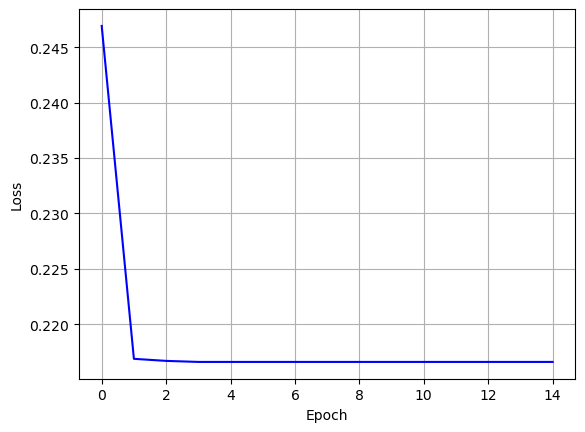

In [9]:
x = list(range(num_epochs))
plt.plot(x, loss_ot, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(
    'loss-overtime.png',
    dpi=600,
    bbox_inches='tight',
    pad_inches=0,
    format='png'
)
plt.show()

# Saving & Loading Model

Save

In [10]:
torch.save(mod_seek, 'mod_seek.pt')

Load

In [11]:
mod_seek = ModSeek(dataset.num_qs, dataset.num_sols)
mod_seek = torch.load('mod_seek.pt')
mod_seek.eval()

C:\Users\agile\AppData\Local\Temp\ipykernel_14852\2495465887.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mod_seek = torch.load('mod_seek.pt')


ModSeek()

# Testing

In [19]:
TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():
    for answered_qs, sols in test_loader:
        batched_probs = torch.sigmoid(mod_seek(answered_qs))
        sols_flattened = sols.reshape(-1)
        
        if (answered_qs.sum(axis=1) <= 15):
            print(sols_flattened)
            print(sols)
        
        for batch_idx, probs in enumerate(batched_probs):
            for i, prob in enumerate(probs):
                if prob >= 0.5 and sols_flattened[i] == 1:
                    TP += 1
                elif prob >= 0.5 and sols_flattened[i] != 1:
                    FP += 1
                elif prob < 0.5 and sols_flattened[i] == 1:
                    FN += 1
                elif prob < 0.5 and sols_flattened[i] != 1:
                    TN += 1

precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f'Precision: {precision}')
print(f'Recall: {recall}')

tensor([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1.])
tensor([[1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
         1.]])
Precision: 0.9174603174603174
Recall: 0.8312559923298178


In [16]:
print(torch.sigmoid(mod_seek.z))

tensor([0.2015, 0.6456, 0.3667, 0.3237, 0.1038, 0.1904, 0.2688, 0.8304, 0.4341,
        0.1742, 0.5034, 0.6928, 0.5189, 0.5725, 0.5003, 0.3492, 0.4130, 0.4218,
        0.2078], grad_fn=<SigmoidBackward0>)
